In [1]:
import os

# Adjust the path to match your Box sync folder location
box_path = os.path.expanduser(r"C:\Users\HIALAB\Box\Human_AGV_project\ISU_Modeling\Code")
# Specify the directory and filename
save_dir = "./Images/"

In [204]:
# base libraries
import numpy as np
import pandas as pd
# regular expression module in python to find all sequences of digits in a given string
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from scipy.spatial.distance import directed_hausdorff
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from datetime import datetime, timedelta
from scipy.stats import gamma
from scipy.stats import gaussian_kde
from scipy.stats import norm
import random
import math
from scipy import stats

%matplotlib inline
from numpy.linalg import inv
from abc import ABC, abstractmethod

In [5]:
data = pd.read_csv(os.path.join(box_path, 'Per_Interaction_Data_Merged.csv'))
study_data = pd.read_csv(os.path.join(box_path, 'study_data_processed.csv'))

In [7]:
data.head()

,PID,DRate,date,hr,min,s,AGVname,StartTime,EndTime,GazeDuration,...,AGV_Path_Complexity,Trust_before,Cross_First_Flag,User_Relative_Speed,AGV_Relative_Speed,Frechet_Distance_3,Frechet_Distance_5,Frechet_Distance_7,Frechet_Distance_10,Cross_First
0,1,High,2024-5-3,14,28,53,1,1900-01-01 15:02:48,1900-01-01 15:03:38,219,...,Straight,103.457506,True,74.580213,100.420508,730.13,1188.92,1532.83,1771.61,N\A
1,1,High,2024-5-3,14,28,53,2,1900-01-01 15:03:47,1900-01-01 15:04:29,0,...,Complex,211.137767,True,47.888087,232.345812,14.56,97.05,108.21,247.34,N\A
2,1,High,2024-5-3,14,28,53,3,1900-01-01 15:04:37,1900-01-01 15:05:34,268,...,Complex,211.137767,True,63.130599,120.176130,282.09,482.54,821.32,1067.08,User
3,1,High,2024-5-3,14,28,53,4,1900-01-01 15:05:46,1900-01-01 15:06:37,779,...,Complex,211.137767,True,43.571998,263.284416,421.34,544.15,577.55,610.84,User
4,1,High,2024-5-3,14,28,53,5,1900-01-01 15:06:41,1900-01-01 15:07:44,868,...,Complex,147.796437,True,93.720008,91.614207,486.65,852.85,1225.51,1722.14,N\A


In [9]:
study_data.head()

,User_X,User_Y,User_Z,User_Pitch,User_Yaw,User_Roll,U_X,U_Y,U_Z,GazeOrigin_X,...,AGV_Yaw,AGV_Roll,AGV_spd,Timestamp,AGVname,PID,DRate,User_Relative_Speed,AGV_Relative_Speed,AGV_User_distance
0,5051.235,8610.83,-209.725,-21.416662,-92.196247,-0.159610,60.524000,-107.387000,156.022000,4990.711200,...,89.999444,0.002393,0.000238,2024-10-25 15:02:48.900,1,1,High,0.0,0.000000,6812.026513
1,5051.235,8610.83,-209.725,-21.168361,-92.384752,0.290698,60.493000,-108.133857,156.034571,4990.742143,...,89.999339,-0.000460,0.154715,2024-10-25 15:02:49.000,1,1,High,0.0,84.241150,6811.521389
2,5051.235,8610.83,-209.725,-21.240655,-92.761660,0.339485,60.271857,-108.963714,156.053429,4990.963429,...,89.999565,-0.001784,0.526054,2024-10-25 15:02:49.100,1,1,High,0.0,74.712591,6809.601293
3,5051.235,8610.83,-209.725,-21.004733,-93.120707,0.251285,59.831714,-109.665143,156.194286,4991.403286,...,90.000198,-0.001954,0.893006,2024-10-25 15:02:49.200,1,1,High,0.0,35.834089,6806.150079
4,5051.235,8610.83,-209.725,-20.717933,-91.225685,0.512156,59.295143,-110.065286,156.430571,4991.940286,...,90.001157,-0.001464,1.263035,2024-10-25 15:02:49.300,1,1,High,0.0,66.574460,6801.168018


In [11]:
study_data.columns

Index(['User_X', 'User_Y', 'User_Z', 'User_Pitch', 'User_Yaw', 'User_Roll',
       'U_X', 'U_Y', 'U_Z', 'GazeOrigin_X', 'GazeOrigin_Y', 'GazeOrigin_Z',
       'GazeDirection_X', 'GazeDirection_Y', 'GazeDirection_Z', 'Confidence',
       'Gaze_on_AGV', 'AGV_X', 'AGV_Y', 'AGV_Z', 'AGV_Pitch', 'AGV_Yaw',
       'AGV_Roll', 'AGV_spd', 'Timestamp', 'AGVname', 'PID', 'DRate',
       'User_Relative_Speed', 'AGV_Relative_Speed', 'AGV_User_distance'],
      dtype='object')

In [13]:
data.columns

Index(['PID', 'DRate', 'date', 'hr', 'min', 's', 'AGVname', 'StartTime',
       'EndTime', 'GazeDuration', 'mean_dist', 'min_dist', 'max_dist',
       'std_dist', 'mean_agv_spd', 'min_agv_spd', 'max_agv_spd', 'std_spd',
       'task', 'Trust', 'Safe', 'Comfort', 'Expect', 'Age', 'Gender',
       'Ethnicity', 'GamingFrequency', 'VRExperience', 'VRHeadsetExperience',
       'AGVInteraction', 'PerfectAutomation', 'TrustPropensity',
       'AutomationExperience', 'Trust1', 'Trust2', 'MWL', 'Assessment',
       'Gaze_on_AGV', 'User_Trajectory', 'AGV_Approaching',
       'AGV_User_Combination', 'AGV_Path_Complexity', 'Trust_before',
       'Cross_First_Flag', 'User_Relative_Speed', 'AGV_Relative_Speed',
       'Frechet_Distance_3', 'Frechet_Distance_5', 'Frechet_Distance_7',
       'Frechet_Distance_10', 'Cross_First'],
      dtype='object')

In [15]:
# Convert 'StartTime' and 'EndTime' to datetime format if they are not already
data['StartTime'] = pd.to_datetime(data['StartTime'])
data['EndTime'] = pd.to_datetime(data['EndTime'])

# Create a new column 'duration' as the difference between 'EndTime' and 'StartTime'
data['Duration'] = (data['EndTime'] - data['StartTime']).dt.total_seconds()

In [17]:
# Define a custom function for reward assignment
def calculate_reward(group):
    group = group.sort_index()  # Ensure rows are in order within the group
    group['Reward'] = 0  # Initialize Reward column with 1
    
    # Compare current Trust with the previous one
    group['Reward'].iloc[1:] = (group['Trust'].iloc[1:].values >= group['Trust'].iloc[:-1].values + 1).astype(int)
    
    return group

# Apply the function to each group
data = data.groupby(['PID', 'DRate']).apply(calculate_reward).reset_index(drop=True)
data[['PID', 'DRate', 'AGVname', 'Trust', 'Reward']].head(40)

C:\Users\HIALAB\AppData\Local\Temp\ipykernel_100572\2528085037.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  group['Reward'].iloc[1:] = (group['Trust'].iloc[1:].values >= group['Trust'].iloc[:-1].values + 1).astype(int)
C:\Users\HIALAB

,PID,DRate,AGVname,Trust,Reward
0,1,High,1,10,0
1,1,High,2,10,0
2,1,High,3,10,0
3,1,High,4,7,0
4,1,High,5,5,0
5,1,High,6,7,1
6,1,High,7,8,1
7,1,High,8,4,0
8,1,High,9,9,1
9,1,High,10,6,0


<Figure size 1200x600 with 0 Axes>

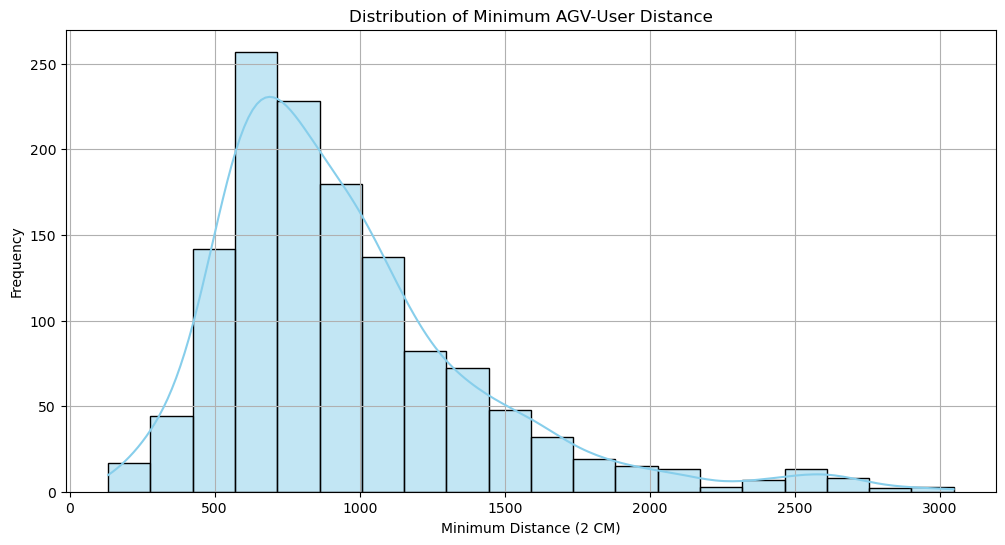

In [28]:
# Group by PID, AGVname, and DRate, then calculate the minimum value of AGV_User_distance
min_distances = study_data.groupby(['PID', 'AGVname', 'DRate'])['AGV_User_distance'].min().reset_index()

# Rename the column for clarity
# min_distances.rename(columns={'AGV_User_distance': 'Min_Distance'}, inplace=True)

# Visualize the distribution of minimum distances
plt.figure(figsize=(12, 6))
sns.histplot(min_distances['AGV_User_distance'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Minimum AGV-User Distance')
plt.xlabel('Minimum Distance (2 CM)')
plt.ylabel('Frequency')
plt.grid(True)

filename = f"Distribution_of_Minimum_AGV-User_Distance.png"
full_path = os.path.join(box_path + save_dir, filename)
# plt.savefig(full_path, dpi=600)

plt.show()

In [30]:
# Create a mapping dictionary from study_data
min_values = study_data.groupby(['PID', 'AGVname', 'DRate'])['AGV_User_distance'].min().to_dict()

# Assign these minimum values to the corresponding groups in model_data
data['AGV_User_Distance_Min'] = data.set_index(['PID', 'AGVname', 'DRate']).index.map(min_values)
data.head()

,PID,DRate,date,hr,min,s,AGVname,StartTime,EndTime,GazeDuration,...,User_Relative_Speed,AGV_Relative_Speed,Frechet_Distance_3,Frechet_Distance_5,Frechet_Distance_7,Frechet_Distance_10,Cross_First,Duration,Reward,AGV_User_Distance_Min
0,1,High,2024-5-3,14,28,53,1,1900-01-01 15:02:48,1900-01-01 15:03:38,219,...,74.580213,100.420508,730.13,1188.92,1532.83,1771.61,N\A,50.0,0,733.135776
1,1,High,2024-5-3,14,28,53,2,1900-01-01 15:03:47,1900-01-01 15:04:29,0,...,47.888087,232.345812,14.56,97.05,108.21,247.34,N\A,42.0,0,995.854779
2,1,High,2024-5-3,14,28,53,3,1900-01-01 15:04:37,1900-01-01 15:05:34,268,...,63.130599,120.176130,282.09,482.54,821.32,1067.08,User,57.0,0,262.097590
3,1,High,2024-5-3,14,28,53,4,1900-01-01 15:05:46,1900-01-01 15:06:37,779,...,43.571998,263.284416,421.34,544.15,577.55,610.84,User,51.0,0,551.672375
4,1,High,2024-5-3,14,28,53,5,1900-01-01 15:06:41,1900-01-01 15:07:44,868,...,93.720008,91.614207,486.65,852.85,1225.51,1722.14,N\A,63.0,0,1661.414906


### Data Analysis

In [33]:
# Get the total number of null values in each column
null_counts = data.isnull().sum()
null_counts

PID                         0
DRate                       0
date                        0
hr                          0
min                         0
s                           0
AGVname                     0
StartTime                   0
EndTime                     0
GazeDuration                0
mean_dist                   0
min_dist                    0
max_dist                    0
std_dist                    0
mean_agv_spd                0
min_agv_spd                 0
max_agv_spd                 0
std_spd                     0
task                        0
Trust                       0
Safe                        0
Comfort                     0
Expect                      0
Age                         0
Gender                      0
Ethnicity                   0
GamingFrequency             0
VRExperience                0
VRHeadsetExperience         0
AGVInteraction              0
PerfectAutomation           0
TrustPropensity             0
AutomationExperience        0
Trust1    

In [35]:
cross_first_data = data[data['Cross_First'].isin(['AGV', 'User'])]
# cross_first_data = cross_first_data.drop(['Cross_First_Flag', 'Trust_before'], axis=1)
cross_first_data['Arm'] = np.where(cross_first_data['Cross_First'] == 'User', 0, 1)
cross_first_data.head()

C:\Users\HIALAB\AppData\Local\Temp\ipykernel_100572\4256853417.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cross_first_data['Arm'] = np.where(cross_first_data['Cross_First'] == 'User', 0, 1)


,PID,DRate,date,hr,min,s,AGVname,StartTime,EndTime,GazeDuration,...,AGV_Relative_Speed,Frechet_Distance_3,Frechet_Distance_5,Frechet_Distance_7,Frechet_Distance_10,Cross_First,Duration,Reward,AGV_User_Distance_Min,Arm
2,1,High,2024-5-3,14,28,53,3,1900-01-01 15:04:37,1900-01-01 15:05:34,268,...,120.176130,282.09,482.54,821.32,1067.08,User,57.0,0,262.097590,0
3,1,High,2024-5-3,14,28,53,4,1900-01-01 15:05:46,1900-01-01 15:06:37,779,...,263.284416,421.34,544.15,577.55,610.84,User,51.0,0,551.672375,0
6,1,High,2024-5-3,14,28,53,7,1900-01-01 15:09:07,1900-01-01 15:09:50,537,...,228.573947,379.71,540.52,665.30,941.60,User,43.0,1,598.393526,0
7,1,High,2024-5-3,14,28,53,8,1900-01-01 15:10:07,1900-01-01 15:11:08,650,...,161.124764,331.78,693.33,1038.91,1483.72,User,61.0,0,705.402875,0
8,1,High,2024-5-3,14,28,53,9,1900-01-01 15:11:12,1900-01-01 15:12:13,856,...,161.124877,115.79,379.19,541.15,1029.62,AGV,61.0,1,572.331091,1


In [133]:
cross_first_data.isnull().sum()

PID                         0
DRate                       0
date                        0
hr                          0
min                         0
s                           0
AGVname                     0
StartTime                   0
EndTime                     0
GazeDuration                0
mean_dist                   0
min_dist                    0
max_dist                    0
std_dist                    0
mean_agv_spd                0
min_agv_spd                 0
max_agv_spd                 0
std_spd                     0
task                        0
Trust                       0
Safe                        0
Comfort                     0
Expect                      0
Age                         0
Gender                      0
Ethnicity                   0
GamingFrequency             0
VRExperience                0
VRHeadsetExperience         0
AGVInteraction              0
PerfectAutomation           0
TrustPropensity             0
AutomationExperience        0
Trust1    

In [39]:
cross_first_data.columns

Index(['PID', 'DRate', 'date', 'hr', 'min', 's', 'AGVname', 'StartTime',
       'EndTime', 'GazeDuration', 'mean_dist', 'min_dist', 'max_dist',
       'std_dist', 'mean_agv_spd', 'min_agv_spd', 'max_agv_spd', 'std_spd',
       'task', 'Trust', 'Safe', 'Comfort', 'Expect', 'Age', 'Gender',
       'Ethnicity', 'GamingFrequency', 'VRExperience', 'VRHeadsetExperience',
       'AGVInteraction', 'PerfectAutomation', 'TrustPropensity',
       'AutomationExperience', 'Trust1', 'Trust2', 'MWL', 'Assessment',
       'Gaze_on_AGV', 'User_Trajectory', 'AGV_Approaching',
       'AGV_User_Combination', 'AGV_Path_Complexity', 'Trust_before',
       'Cross_First_Flag', 'User_Relative_Speed', 'AGV_Relative_Speed',
       'Frechet_Distance_3', 'Frechet_Distance_5', 'Frechet_Distance_7',
       'Frechet_Distance_10', 'Cross_First', 'Duration', 'Reward',
       'AGV_User_Distance_Min', 'Arm'],
      dtype='object')

   Cross_First  Trust  Count  Percentage
0          AGV      1      4    0.564175
1          AGV      2      1    0.141044
2          AGV      3     10    1.410437
3          AGV      4     18    2.538787
4          AGV      5     33    4.654443
5          AGV      6     39    5.500705
6          AGV      7     92   12.976023
7          AGV      8    148   20.874471
8          AGV      9    109   15.373766
9          AGV     10    255   35.966150
10        User      1      3    0.833333
11        User      2      1    0.277778
12        User      4      5    1.388889
13        User      5      9    2.500000
14        User      6     15    4.166667
15        User      7     27    7.500000
16        User      8     44   12.222222
17        User      9     84   23.333333
18        User     10    172   47.777778


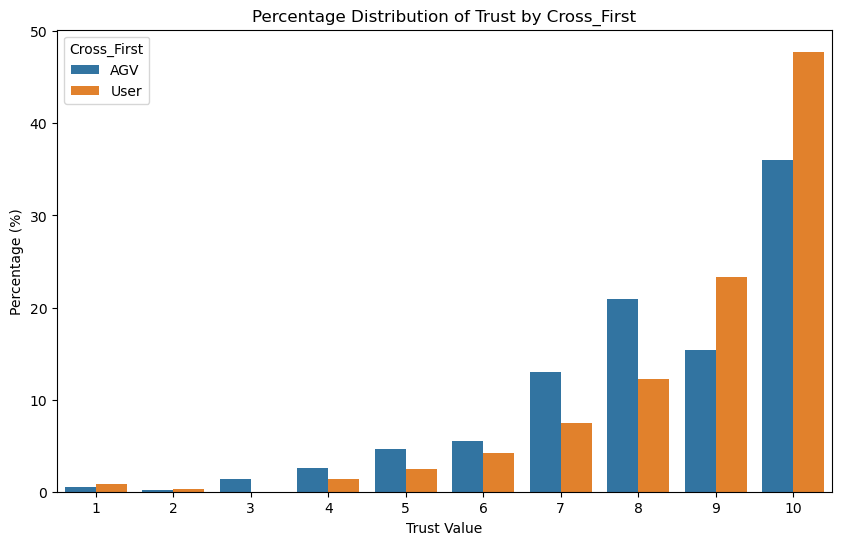

In [41]:
trust_distribution =cross_first_data.groupby(['Cross_First', 'Trust']).size().reset_index(name='Count')

# Calculate the percentage distribution
total_counts = trust_distribution.groupby('Cross_First')['Count'].transform('sum')
trust_distribution['Percentage'] = (trust_distribution['Count'] / total_counts) * 100

# Print the result
print(trust_distribution)

# Optional: Plotting
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(data=trust_distribution, x='Trust', y='Percentage', hue='Cross_First')
plt.title('Percentage Distribution of Trust by Cross_First')
plt.ylabel('Percentage (%)')
plt.xlabel('Trust Value')
plt.legend(title='Cross_First')
plt.show()

  Cross_First  Reward  Count  Percentage
0         AGV       0    573   80.818054
1         AGV       1    136   19.181946
2        User       0    272   75.555556
3        User       1     88   24.444444


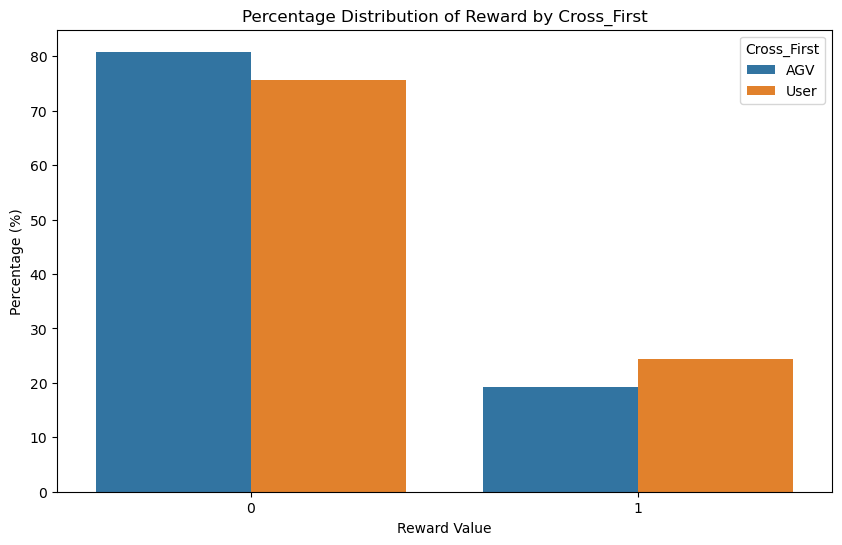

In [43]:
trust_distribution =cross_first_data.groupby(['Cross_First', 'Reward']).size().reset_index(name='Count')

# Calculate the percentage distribution
total_counts = trust_distribution.groupby('Cross_First')['Count'].transform('sum')
trust_distribution['Percentage'] = (trust_distribution['Count'] / total_counts) * 100

# Print the result
print(trust_distribution)

# Optional: Plotting
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(data=trust_distribution, x='Reward', y='Percentage', hue='Cross_First')
plt.title('Percentage Distribution of Reward by Cross_First')
plt.ylabel('Percentage (%)')
plt.xlabel('Reward Value')
plt.legend(title='Cross_First')
filename = f'Percentage Distribution of Reward based on Cross_First Decisions.png'
full_path = os.path.join(box_path + save_dir, filename)  
# plt.savefig(full_path, dpi=300)
plt.show()

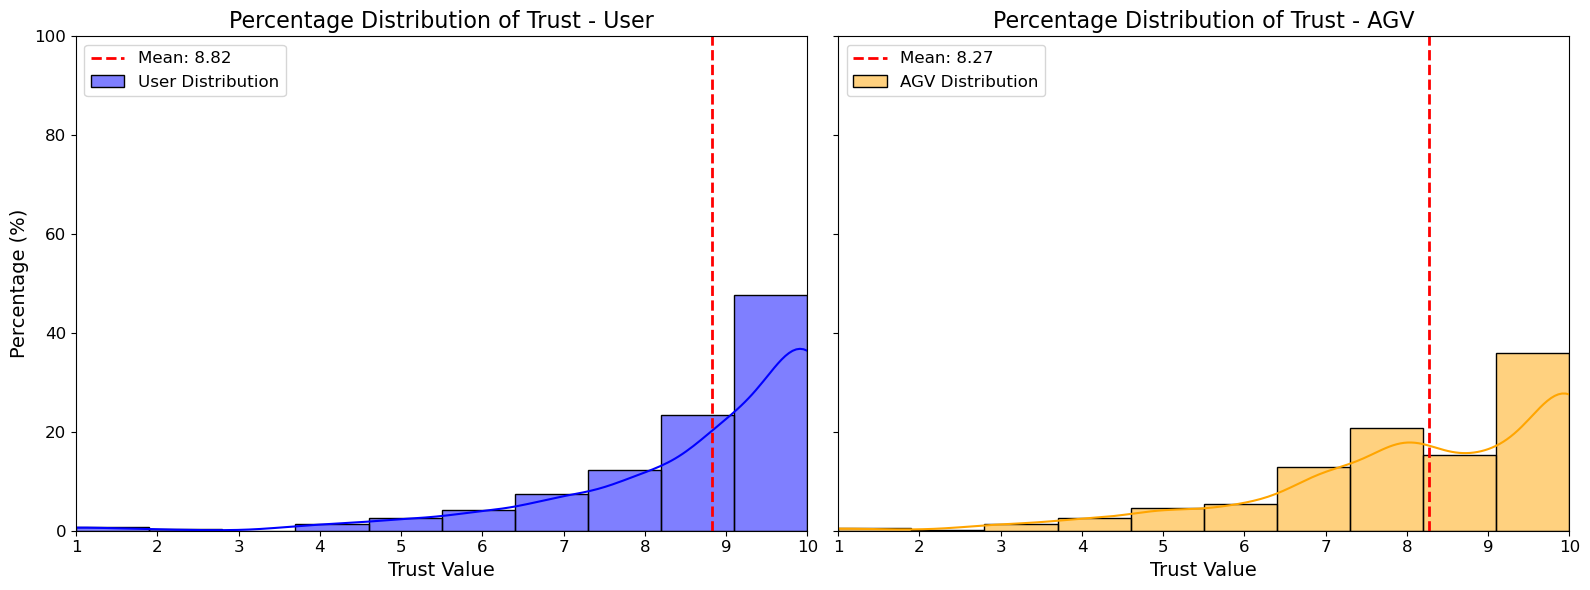

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Calculate means
user_mean = cross_first_data[(cross_first_data['Cross_First'] == 'User')]['Trust'].mean()
agv_mean = cross_first_data[(cross_first_data['Cross_First'] == 'AGV')]['Trust'].mean()

# Extract Trust data for both groups with the additional DRate condition
user_trust_data = cross_first_data[(cross_first_data['Cross_First'] == 'User')]['Trust']
agv_trust_data = cross_first_data[(cross_first_data['Cross_First'] == 'AGV')]['Trust']

# Fit KDE for User data
user_kde = gaussian_kde(user_trust_data)
user_x_values = np.linspace(user_trust_data.min(), user_trust_data.max(), 100)
user_kde_values = user_kde(user_x_values)

# Fit KDE for AGV data
agv_kde = gaussian_kde(agv_trust_data)
agv_x_values = np.linspace(agv_trust_data.min(), agv_trust_data.max(), 100)
agv_kde_values = agv_kde(agv_x_values)

# Plot for User
sns.histplot(
    data=cross_first_data[cross_first_data['Cross_First'] == 'User'], 
    x='Trust', 
    stat='percent',  # Display percentages
    bins=10, 
    color='blue', 
    ax=axes[0], 
    kde=True,  # Kernel density estimation
    label='User Distribution'
)
axes[0].axvline(user_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {user_mean:.2f}')
axes[0].set_title('Percentage Distribution of Trust - User', fontsize=16)
axes[0].set_ylabel('Percentage (%)', fontsize=14)
axes[0].set_xlabel('Trust Value', fontsize=14)
axes[0].tick_params(axis='both', labelsize=12)
axes[0].set_xlim(1, 10)
axes[0].set_ylim(0, 100)
axes[0].legend(fontsize=12)

# Plot for AGV
sns.histplot(
    data=cross_first_data[cross_first_data['Cross_First'] == 'AGV'], 
    x='Trust', 
    stat='percent',  # Display percentages
    bins=10, 
    color='orange', 
    ax=axes[1], 
    kde=True,  # Kernel density estimation
    label='AGV Distribution'
)
axes[1].axvline(agv_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {agv_mean:.2f}')
axes[1].set_title('Percentage Distribution of Trust - AGV', fontsize=16)
axes[1].set_xlabel('Trust Value', fontsize=14)
axes[1].tick_params(axis='both', labelsize=12)
axes[1].set_xlim(1, 10)
axes[1].set_ylim(0, 100)
axes[1].legend(fontsize=12)

# Show the combined plot
plt.tight_layout()
filename = f'Percentage Distribution of Trust based on Different Decisions.png'
full_path = os.path.join(box_path + save_dir, filename)  
# plt.savefig(full_path, dpi=300)
plt.show()

In [47]:
# Function to calculate mean and error bars for 99.99% confidence
def calculate_confidence_interval(data, confidence_level=0.9999):
    n = len(data)  # Number of samples
    mean = np.mean(data)
    std = np.std(data, ddof=1)  # Sample standard deviation
    standard_error = std / np.sqrt(n)
    
    # Z-score for the given confidence level
    z_score = norm.ppf(1 - (1 - confidence_level) / 2)
    
    # Calculate the margin of error
    error = z_score * standard_error
    return mean, error

# Calculate for User
user_mean, user_error = calculate_confidence_interval(user_trust_data)

# Calculate for AGV
agv_mean, agv_error = calculate_confidence_interval(agv_trust_data)

# Print results with two significant figures
print(f"User Trust: Mean = {user_mean:.2g}, Error = ±{user_error:.2g}")
print(f"AGV Trust: Mean = {agv_mean:.2g}, Error = ±{agv_error:.2g}")

User Trust: Mean = 8.8, Error = ±0.33
AGV Trust: Mean = 8.3, Error = ±0.27


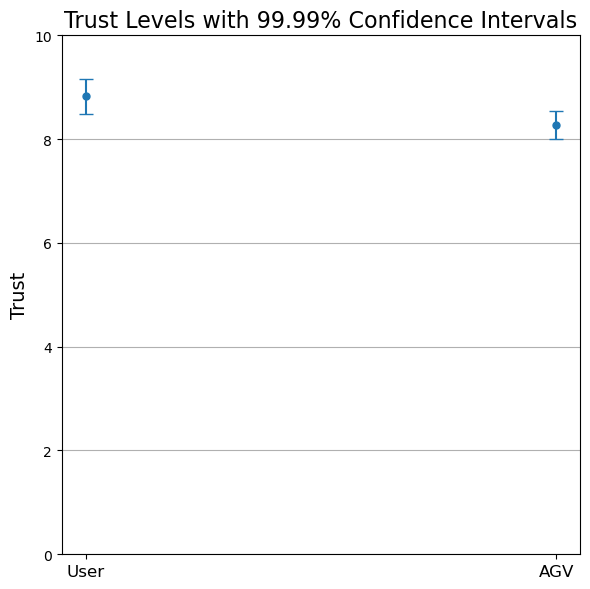

In [49]:
categories = ['User', 'AGV']
means = [user_mean, agv_mean]
errors = [user_error, agv_error]

# Map categorical positions to numerical values
x_positions = [0, 0.5]  # Set custom positions for the points

# Create plot
plt.figure(figsize=(6, 6))
plt.errorbar(x_positions, means, yerr=errors, fmt='o', capsize=5, markersize=5)  # Use fmt='o' for dots
plt.xticks(x_positions, categories, fontsize=12)  # Adjust x-tick label size
plt.ylabel('Trust', fontsize=14)  # Adjust y-axis label size
plt.title('Trust Levels with 99.99% Confidence Intervals', fontsize=16)  # Adjust title size
plt.grid(axis='y')
plt.ylim(0, 10)

# Show plot
plt.tight_layout()
plt.show()

In [51]:
class MAB(ABC):   
    @abstractmethod
    def play(self, numIt, context):
        # Current round of t (for my implementations average mean reward array 
        # at round t is passed to this function instead of tround itself)
        self.numIt = numIt
        # Context: features of contextual bandits
        self.context = context
        # choose an arm which yields maximum value of average mean reward, tie breaking randomly
        chosen_arm = np.random.choice(np.where(self.numIt==max(self.numIt))[0])
        return chosen_arm
        pass
        
    
    @abstractmethod
    def update(self, arm, reward, context):
        # get the chosen arm
        self.arm = arm
        # get the context (may be None)
        self.context = context
        # update the overall step of the model
        self.current_step += 1
        # update the step of individual arms
        self.step_arm[self.arm] += 1
        # update average mean reward of each arm
        self.AM_reward[self.arm] = ((self.step_arm[self.arm] - 1) / float(self.step_arm[self.arm]) 
        * self.AM_reward[self.arm] + (1 / float(self.step_arm[self.arm])) * reward)
        return
        pass

### Epsilon-Greedy Multi-armed Bandit

- The number of arms is denoted by $N$. In this problem $N = 2$.
- The action is denoted by $a_i$, where $i = 1, 2, \dots, N$. The action $a_i$ is actually the selection of the arms $i$. In this problem with have $a_1$ and $a_2$.
- The action selected at the time step $k$ is denoted by $A_k$. Note that $A_k$ is a random variable.
- The action $A_k$ can take different numerical values $a_1, a_2, \dots, a_N$. 
- Every action $A_k$ at the time step $k$, produces a reward that we denote by $R_k$. Note that $R_k$ is a random variable.
- The expected or the mean reward of the action we take is referred to as **the value of that action**. Mathematically speaking, the value is defined by:

$$
v_i = v(a_i) = \mathbb{E}[R_k \mid A_k = a_i]
$$

In our case $v_1 = 8.82$ and $v_2 = 8.27$.

In [55]:
class epsilon_greedy(object):  
    def __init__(self, arms, kde_models, action_values, epsilon, numIt, seed = None):
        """
        @type trueActionValues: means of the normal distributions used to generate random rewards
        @type arms: an integer indicating the number of arms.
        @type epsilon: a float indicating the probability value for selecting non-greedy actions.
        @type numIt: an integer indicating the maximum number of iterations.
        """
        self.arms = arms
        self.epsilon = epsilon  
        self.numIt = numIt
        
        #current step 
        self.current_step = 0

        self.kde_models = kde_models
        
        #this variable tracks how many times a particular arm is being selected
        self.arm_selection_count = np.zeros(self.arms)

        # true action values that are expectations of rewards for arms
        self.action_values = action_values

        # vector that stores mean rewards of every arm
        self.average_rewards = np.zeros(self.arms)
        
        # variable that stores the current value of reward
        self.current_reward = 0;
        
        # mean reward 
        self.mean_reward = np.zeros(numIt + 1)
        
        if seed is not None:
            random.seed(seed)  # Set seed for random module
            np.random.seed(seed)
        
    # select actions according to the epsilon-greedy approach
    def run(self):
        # draw a real number from the uniform distribution on [0,1]
        # this number is our probability of performing greedy actions
        # if this probabiligy is larger than epsilon, we perform greedy actions
        # otherwise, we randomly select an arm 
        for i in range(self.numIt):
            # If we're at the initial step or the probability is smaller than epsilon we select a random arm since all the mean rewards are zero
            if (self.current_step == 0) or (random.uniform(0, 1) <= self.epsilon):
                selected_arm = np.random.choice(self.arms)
             # Otherwise, we select the arm that has the largest average reward so far
            if (random.uniform(0, 1) > self.epsilon):
                selected_arm = np.argmax(self.average_rewards)
  
            # increase the step value  
            self.current_step = self.current_step + 1
            
            # take a record that the particular arm is selected 
            self.arm_selection_count[selected_arm] = self.arm_selection_count[selected_arm] + 1
            
            self.current_reward = self.kde_models[selected_arm].resample(1)[0]
            while self.current_reward > 10:
                self.current_reward = self.kde_models[selected_arm].resample(1)[0]
            
            # update the estimate of the mean reward
            self.mean_reward[self.current_step] = self.mean_reward[self.current_step - 1] + (1/(self.current_step))*(self.current_reward - self.mean_reward[self.current_step - 1])
            
            # update the estimate of the mean reward for the selected arm 
            self.average_rewards[selected_arm] = self.average_rewards[selected_arm]+(1/(self.arm_selection_count[selected_arm]))*(self.current_reward - self.average_rewards[selected_arm])

            # if self.current_step == self.numIt - 1: print(f"The average value of reward is {self.mean_reward}.")

The average value that will be used is 8.825 and 8.273624823695345.


C:\Users\HIALAB\AppData\Local\Temp\ipykernel_100572\3610713144.py:62: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  self.mean_reward[self.current_step] = self.mean_reward[self.current_step - 1] + (1/(self.current_step))*(self.current_reward - self.mean_reward[self.current_step - 1])
C:\Users\HIALAB\AppData\Local\Temp\ipykernel_100572\3610713144.py:65: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  self.average_rewards[selected_arm] = self.average_rewards[selected_arm]+(1/(self.arm_selection_count[selected_arm]))*(self.current_reward - self.average_rewards[selected_arm])


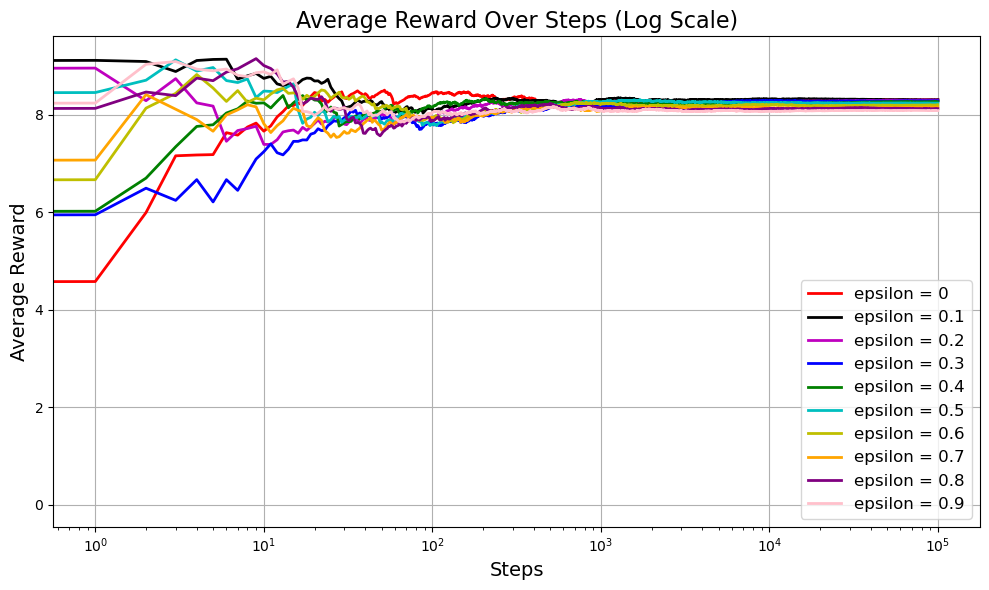

In [57]:
# these are the means of the action values that are used to simulate the multi-armed bandit problem
print(f"The average value that will be used is {user_mean} and {agv_mean}.")
action_values = np.array([user_mean, agv_mean])
# Create KDE models for each arm
kde_models = {
    0: user_kde,  # KDE for User data
    1: agv_kde    # KDE for AGV data
}

# Number of arms
arms = len(kde_models)
numIt = 100000

# Epsilon values
epsilon_values = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Initialize lists to store mean rewards
mean_rewards = []

# Run the epsilon-greedy algorithm for each epsilon value
for epsilon in epsilon_values:
    bandit = epsilon_greedy(arms=arms, kde_models=kde_models, action_values=action_values, epsilon=epsilon, numIt=numIt, seed=None)
    bandit.run()
    mean_rewards.append(bandit.mean_reward)

# Set the size of the plot
plt.figure(figsize=(10, 6))  # Width = 10, Height = 6

# Plot the results for each epsilon value
colors = ['r', 'k', 'm', 'b', 'g', 'c', 'y', 'orange', 'purple', 'pink']  # Color list for different epsilon values
for i, epsilon in enumerate(epsilon_values):
    plt.plot(np.arange(numIt + 1), mean_rewards[i], linewidth=2, color=colors[i], label=f'epsilon = {epsilon}')

# Add title and axis labels
plt.title('Average Reward Over Steps (Log Scale)', fontsize=16)  # Title with custom size
plt.xlabel('Steps', fontsize=14)  # X-axis label with custom size
plt.ylabel('Average Reward', fontsize=14)  # Y-axis label with custom size
plt.xscale('log') 
plt.grid(True)

# Customize the legend
plt.legend(fontsize=12)  # Set the font size of the legend

filename = f'Average Reward Over Steps (Log Scale).png'
full_path = os.path.join(box_path + save_dir, filename)  
# plt.savefig(full_path, dpi=300)

# Display the plot
plt.tight_layout()
plt.show()

### Contextual Bandit

- The number of arms is denoted by $N$. In this problem $N = 2$.
- The action is denoted by $a_i$, where $i = 1, 2, \dots, N$. The action $a_i$ is actually the selection of the arms $i$. In this problem we have $a_1$ and $a_2$.
- The action selected at the time step $k$ is denoted by $A_k$. Note that $A_k$ is a random variable.
- The action $A_k$ can take different numerical values $a_1, a_2, \dots, a_N$. In this problem we have $a_1$ and $a_2$.
- Every action $A_k$ at the time step $k$, produces a reward that we denote by $R_k$. Note that $R_k$ is a random variable with minimum of 0 and maximum of 1.
- The expected or the mean reward of the action we take is referred to as **the value of that action**. Mathematically speaking, the value is defined by:

$$
v_i = v(a_i) = \mathbb{E}[R_k \mid A_k = a_i]
$$

- The context is the following, which will be scaled:
$$
['GazeDuration', 'mean\_dist', 'min\_dist', 'max\_dist',
'std\_dist', 'mean\_agv\_spd', 'min\_agv\_spd', 'max\_agv\_spd', 'std\_spd',
'GamingFrequency', 'VRExperience',
$$

$$
'VRHeadsetExperience', 'AGVInteraction', 'PerfectAutomation', 
'TrustPropensity', 'AutomationExperience',
$$

$$
'User\_Relative\_Speed', 'AGV\_Relative\_Speed', 
'Frechet\_Distance\_10', 'Duration', 'AGV\_User\_Distance\_Min']           
$$

In [279]:
columns = ['GazeDuration', 'mean_dist', 'min_dist', 'max_dist',
       'std_dist', 'mean_agv_spd', 'min_agv_spd', 'max_agv_spd', 'std_spd', 'PerfectAutomation', 'TrustPropensity',
       'AutomationExperience','User_Relative_Speed', 'AGV_Relative_Speed', 'Frechet_Distance_10', 'Duration', 'AGV_User_Distance_Min', 'Arm', 'Trust']
columns_to_scale = ['GazeDuration', 'mean_dist', 'min_dist', 'max_dist',
       'std_dist', 'mean_agv_spd', 'min_agv_spd', 'max_agv_spd', 'std_spd', 'PerfectAutomation', 'TrustPropensity',
       'AutomationExperience','User_Relative_Speed', 'AGV_Relative_Speed', 'Frechet_Distance_10', 'Duration', 'AGV_User_Distance_Min', 'Trust']
context = ['GazeDuration', 'mean_dist', 'min_dist', 'max_dist',
       'std_dist', 'mean_agv_spd', 'min_agv_spd', 'max_agv_spd', 'std_spd', 'PerfectAutomation', 'TrustPropensity',
       'AutomationExperience','User_Relative_Speed', 'AGV_Relative_Speed', 'Frechet_Distance_10', 'Duration', 'AGV_User_Distance_Min']

#### Bandit Data

In [282]:
bandit_data = cross_first_data[columns].copy()
bandit_data.head()

,GazeDuration,mean_dist,min_dist,max_dist,std_dist,mean_agv_spd,min_agv_spd,max_agv_spd,std_spd,PerfectAutomation,TrustPropensity,AutomationExperience,User_Relative_Speed,AGV_Relative_Speed,Frechet_Distance_10,Duration,AGV_User_Distance_Min,Arm,Trust
2,268,2950.96,251.42,4932.64,2029.11,3.24,-5.60,15.22,5.28,3.571,3.667,3.917,63.130599,120.176130,1067.08,57.0,262.097590,0,10
3,779,5286.88,546.37,11770.31,4347.37,7.20,-3.50,15.25,6.62,3.571,3.667,3.917,43.571998,263.284416,610.84,51.0,551.672375,0,7
6,537,3361.51,593.85,5470.69,1960.51,5.04,-4.18,15.22,5.89,3.571,3.667,3.917,62.064945,228.573947,941.60,43.0,598.393526,0,8
7,650,2798.34,701.58,4593.82,1202.09,3.63,-4.40,15.22,5.21,3.571,3.667,3.917,59.394993,161.124764,1483.72,61.0,705.402875,0,4
8,856,4101.88,566.84,6942.89,1915.34,3.58,-4.40,15.22,4.80,3.571,3.667,3.917,59.041137,161.124877,1029.62,61.0,572.331091,1,9


In [284]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_features = pd.DataFrame(scaler.fit_transform(bandit_data[columns_to_scale]),
                               columns=columns_to_scale,
                               index=bandit_data.index)

# Preserve the other columns (e.g., the key or identifier)
other_columns = bandit_data.drop(columns = columns_to_scale)

bandit_data = pd.concat([other_columns, scaled_features], axis=1)
bandit_data.head()

,Arm,GazeDuration,mean_dist,min_dist,max_dist,std_dist,mean_agv_spd,min_agv_spd,max_agv_spd,std_spd,PerfectAutomation,TrustPropensity,AutomationExperience,User_Relative_Speed,AGV_Relative_Speed,Frechet_Distance_10,Duration,AGV_User_Distance_Min,Trust
2,0,0.048141,0.233868,0.041578,0.187786,0.354049,0.234940,0.537572,0.972403,0.736134,0.722006,0.875469,0.250094,0.269346,0.245112,0.360337,0.183246,0.044412,1.000000
3,0,0.139932,0.535193,0.142728,0.899678,0.866515,0.632530,0.710983,0.977273,0.961345,0.722006,0.875469,0.250094,0.156120,0.638370,0.206271,0.151832,0.143750,0.666667
6,0,0.096461,0.286828,0.159011,0.243804,0.338884,0.415663,0.654831,0.972403,0.838655,0.722006,0.875469,0.250094,0.263176,0.542987,0.317964,0.109948,0.159778,0.777778
7,0,0.116759,0.214181,0.195955,0.152510,0.171230,0.274096,0.636664,0.972403,0.724370,0.722006,0.875469,0.250094,0.247720,0.357638,0.501030,0.204188,0.196488,0.333333
8,1,0.153763,0.382332,0.149748,0.397079,0.328899,0.269076,0.636664,0.972403,0.655462,0.722006,0.875469,0.250094,0.245672,0.357638,0.347687,0.204188,0.150837,0.888889


In [286]:
def train_experts(data, context_cols, arm_col='Arm', reward_col='Trust', num_experts=3):
    """
    Train num_experts models, each using the context to estimate the reward of each arm.
    For simplicity:
      - We'll randomly partition data among the experts.
      - Each expert will train a separate linear regression per arm to predict rewards from context.
    """
    # Identify the unique arms
    unique_arms = data[arm_col].unique()
    K = len(unique_arms)
    arm_to_idx = {arm: idx for idx, arm in enumerate(unique_arms)}
    
    # Randomly split the dataset into 'num_experts' portions (toy approach)
    data['expert_id'] = np.random.choice(range(num_experts), size=len(data))

    # For each expert, train a separate model for each arm
    experts_models = []
    for expert_id in range(num_experts):
        # Subset data for this expert
        data_expert = data[data['expert_id'] == expert_id]
        
        # We'll store a list of models: one model per arm
        # Each model predicts reward given the context for that arm
        arm_models = []
        for arm in unique_arms:
            # Subset only rows where this arm was actually chosen (to get reward)
            data_arm = data_expert[data_expert[arm_col] == arm]
            
            if len(data_arm) == 0:
                # No data for this expert-arm combo, fallback to a dummy model
                # that always predicts, say, mean reward or 0
                model = None
            else:
                # Train a basic regression model (or could do classification etc.)
                X = data_arm[context_cols].values
                y = data_arm[reward_col].values
                model = LinearRegression()
                model.fit(X, y)
            
            arm_models.append(model)
        
        experts_models.append(arm_models)
    
    # Cleanup
    data.drop(columns=['expert_id'], inplace=True)
    
    return experts_models, unique_arms

In [288]:
def expert_predict(experts_models, unique_arms, expert_id, x_t):
    """
    Given the trained models for each arm of a particular expert,
    return a probability distribution over arms based on the current context x_t.

    We'll do:
      - For each arm, predict reward via the model
      - Convert predicted rewards to probabilities by softmax
    """
    arm_models = experts_models[expert_id]
    
    # Predict reward for each arm
    preds = []
    for model in arm_models:
        if model is None:
            preds.append(0.0)
        else:
            # model.predict expects 2D input
            pred_reward = model.predict(x_t.reshape(1, -1))[0]
            preds.append(pred_reward)
    
    # Softmax to get distribution
    exps = np.exp(preds)
    sum_exps = np.sum(exps)
    if sum_exps <= 1e-12:
        # Avoid divide-by-zero
        return np.ones(len(arm_models)) / len(arm_models)
    else:
        return exps / sum_exps

In [290]:
def generate_expert_functions(experts_models, unique_arms):
    """
    Return a list of expert functions that each produce a distribution over arms
    given context x_t.
    """
    num_experts = len(experts_models)

    def make_expert_fn(expert_id):
        def fn(x_t):
            return expert_predict(experts_models, unique_arms, expert_id, x_t)
        return fn
    
    # Create a function for each expert
    expert_fns = []
    for i in range(num_experts):
        expert_fns.append(make_expert_fn(i))
    
    return expert_fns

In [292]:
def exp4_offline_with_context(df, context_cols,
                              arm_col='Arm', reward_col='Trust',
                              num_experts=3, gamma=0.1):
    """
    Apply Exp4 in an offline manner using context-based experts.
    """
    # -- 1) Identify arms --
    unique_arms = df[arm_col].unique()
    arm_to_idx = {arm: idx for idx, arm in enumerate(unique_arms)}
    K = len(unique_arms)
    
    # -- 2) Train experts on the dataset to predict reward from context
    experts_models, unique_arms = train_experts(df, context_cols, arm_col, reward_col, num_experts)
    # Create expert "distribution" functions
    experts = generate_expert_functions(experts_models, unique_arms)
    
    # -- 3) Initialize expert weights --
    w = np.ones(num_experts)
    
    reward_history = []
    
    # -- 4) Iterate over rows (simulate online setting) --
    for t, row in df.iterrows():
        x_t = row[context_cols].values  # context vector
        actual_arm = row[arm_col]
        actual_reward = row[reward_col]
        actual_arm_idx = arm_to_idx[actual_arm]
        
        # 4a) Get each expert's distribution
        Q = np.array([expert_fn(x_t) for expert_fn in experts])  # shape: (num_experts, K)
        
        # 4b) Combine experts into a single distribution p_t
        w_sum = w.sum()
        mixture = np.dot(w, Q) / w_sum  # shape (K,)
        p_t = (1 - gamma) * mixture + (gamma / K)
        
        # 4c) Sample from p_t (offline simulation)
        chosen_arm_idx = np.random.choice(range(K), p=p_t)
        
        # 4d) Determine reward for chosen arm
        if chosen_arm_idx == actual_arm_idx:
            r_t = actual_reward
        else:
            r_t = 0.0
        
        # 4e) Estimated reward
        r_hat = np.zeros(K)
        r_hat[chosen_arm_idx] = r_t / max(p_t[chosen_arm_idx], 1e-12)
        
        # 4f) Update expert weights
        for i in range(num_experts):
            w[i] *= np.exp(
                gamma * r_hat[chosen_arm_idx] * Q[i][chosen_arm_idx] / K
            )
        
        reward_history.append(r_t)
    
    return w, reward_history

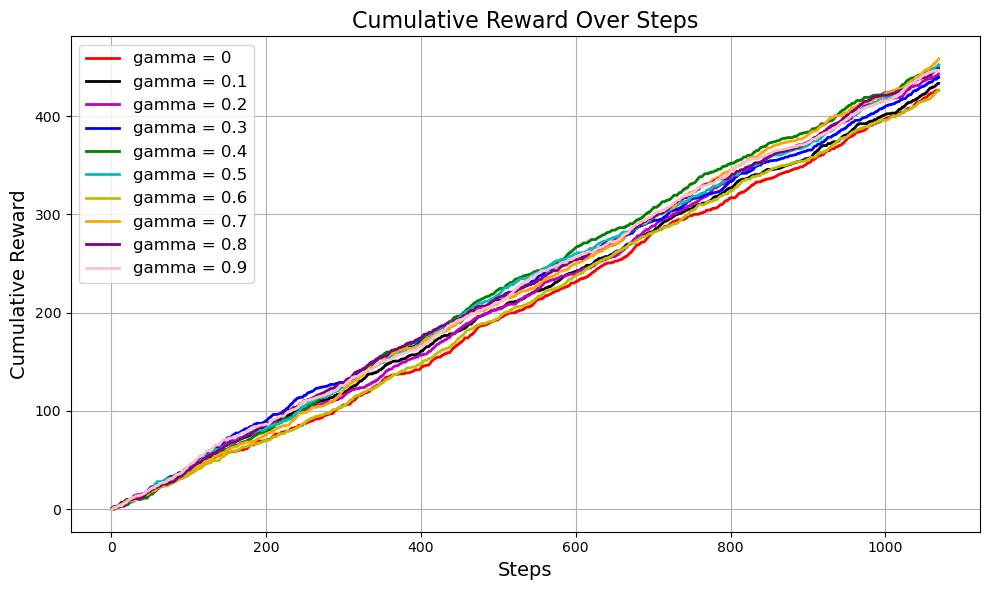

In [294]:
context_cols = ['GazeDuration', 'mean_dist', 'min_dist', 'max_dist',
       'std_dist', 'mean_agv_spd', 'min_agv_spd', 'max_agv_spd', 'std_spd', 'PerfectAutomation', 'TrustPropensity',
       'AutomationExperience','User_Relative_Speed', 'AGV_Relative_Speed', 'Frechet_Distance_10', 'Duration', 'AGV_User_Distance_Min']

# Example gamma values
gamma_values = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# We'll store cumulative rewards (one array per gamma)
cumulative_rewards_for_all = []

# Run Exp4 for each gamma, collect the final weights and reward histories
for gamma in gamma_values:
    final_weights, reward_history = exp4_offline_with_context(
        bandit_data,
        context_cols,
        arm_col='Arm',
        reward_col='Trust',
        num_experts=3,
        gamma=gamma
    )
    # Convert per-step rewards into cumulative sum
    cumulative_rewards = np.cumsum(reward_history)
    cumulative_rewards_for_all.append(cumulative_rewards)

# --------------------------------
# Now we plot all curves together
# --------------------------------

plt.figure(figsize=(10, 6))  

# Distinguishable colors for each gamma
colors = ['r', 'k', 'm', 'b', 'g', 'c', 'y', 'orange', 'purple', 'pink']  

for i, gamma in enumerate(gamma_values):
    # x-axis: steps from 1..T
    steps = np.arange(1, len(cumulative_rewards_for_all[i]) + 1)
    # y-axis: cumulative rewards
    plt.plot(steps, cumulative_rewards_for_all[i],
             linewidth=2, color=colors[i], label=f'gamma = {gamma}')

# Title and labels
plt.title('Cumulative Reward Over Steps', fontsize=16)
plt.xlabel('Steps', fontsize=14)
plt.ylabel('Cumulative Reward', fontsize=14)

# Use a log-scale on the x-axis
# plt.xscale('log')

# Turn on the grid
plt.grid(True)

# Legend
plt.legend(fontsize=12)
filename = f'Exp4 - Cumulative Reward Over Steps.png'
full_path = os.path.join(box_path + save_dir, filename)  
# plt.savefig(full_path, dpi=300)


plt.tight_layout()
# Show the figure
plt.show()

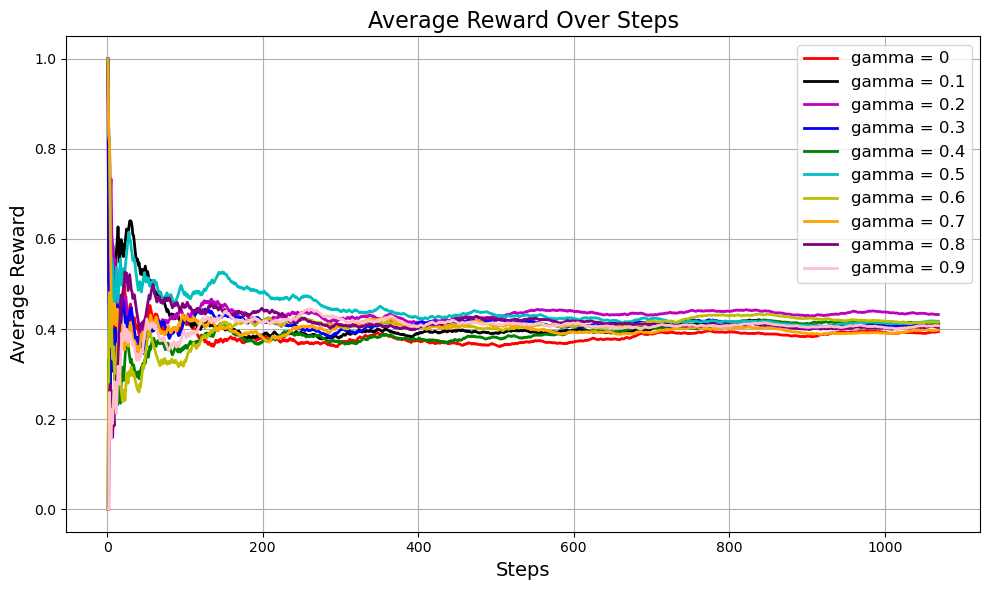

In [296]:
# Example gamma values
gamma_values = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# We'll store average rewards (one array per gamma)
avg_rewards_for_all = []

# Run Exp4 for each gamma, collect the final weights and reward histories
for gamma in gamma_values:
    final_weights, reward_history = exp4_offline_with_context(
        bandit_data,
        context_cols=context_cols,
        arm_col='Arm',
        reward_col='Trust',
        num_experts=3,
        gamma=gamma
    )
    # Convert per-step rewards into cumulative sum
    cumulative_rewards = np.cumsum(reward_history)
    
    # Compute the average reward at each step
    steps = np.arange(1, len(cumulative_rewards) + 1)
    average_rewards = cumulative_rewards / steps  # element-wise division
    
    avg_rewards_for_all.append(average_rewards)

# --------------------------------
# Now we plot all curves together
# --------------------------------

plt.figure(figsize=(10, 6))  

# Distinguishable colors for each gamma
colors = ['r', 'k', 'm', 'b', 'g', 'c', 'y', 'orange', 'purple', 'pink']  

for i, gamma in enumerate(gamma_values):
    # x-axis: steps from 1..T
    steps = np.arange(1, len(avg_rewards_for_all[i]) + 1)
    
    # y-axis: average reward
    plt.plot(steps, avg_rewards_for_all[i],
             linewidth=2, color=colors[i], label=f'gamma = {gamma}')

# Title and labels
plt.title('Average Reward Over Steps', fontsize=16)
plt.xlabel('Steps', fontsize=14)
plt.ylabel('Average Reward', fontsize=14)

# Use a log-scale on the x-axis (optional)
# plt.xscale('log')

# Turn on the grid
plt.grid(True)

# Legend
plt.legend(fontsize=12)
filename = f'Exp4 - Average Reward Over Steps.png'
full_path = os.path.join(box_path + save_dir, filename)  
# plt.savefig(full_path, dpi=300)


plt.tight_layout()
# Show the figure
plt.show()

In [298]:
final_cum_rewards = []  # store the final cumulative reward for each gamma

for i, gamma in enumerate(gamma_values):
    # The final cumulative reward is the last element in the cumulative_rewards array
    last_value = cumulative_rewards_for_all[i][-1]
    final_cum_rewards.append(last_value)

# Find which gamma is best
best_gamma_cum = gamma_values[np.argmax(final_cum_rewards)]
best_cum_value = np.max(final_cum_rewards)
print("Best gamma for final cumulative reward:", best_gamma_cum)
print("Maximum final cumulative reward:", best_cum_value)

Best gamma for final cumulative reward: 0.7
Maximum final cumulative reward: 458.3333333333346


In [300]:
final_avg_rewards = []  # store final average reward for each gamma

for i, gamma in enumerate(gamma_values):
    # Final average reward is the last element in that array
    last_value = avg_rewards_for_all[i][-1]
    final_avg_rewards.append(last_value)

# Find which gamma is best
best_gamma_avg = gamma_values[np.argmax(final_avg_rewards)]
best_avg_value = np.max(final_avg_rewards)

print("Best gamma for final average reward:", best_gamma_avg)
print("Maximum final average reward:", best_avg_value)

Best gamma for final average reward: 0.2
Maximum final average reward: 0.43228354640889827


In [302]:
# We'll store final results in dictionaries
final_results = {}

# 1) Best gamma for cumulative reward
final_weights_cum, reward_history_cum = exp4_offline_with_context(
    bandit_data,
    context_cols=context_cols,
    arm_col='Arm',
    reward_col='Trust',
    num_experts=3,
    gamma=best_gamma_cum
)

cum_cum = np.cumsum(reward_history_cum)
final_cum_cum_reward = cum_cum[-1]                # final cumulative
final_cum_avg_reward = final_cum_cum_reward / len(cum_cum)  # final average

final_results[f"Exp4 (gamma={best_gamma_cum}, best-cum)"] = {
    "cumulative": final_cum_cum_reward,
    "average": final_cum_avg_reward
}

# 2) Best gamma for average reward
final_weights_avg, reward_history_avg = exp4_offline_with_context(
    bandit_data,
    context_cols=context_cols,
    arm_col='Arm',
    reward_col='Trust',
    num_experts=3,
    gamma=best_gamma_avg
)

cum_avg = np.cumsum(reward_history_avg)
final_cum_avg_reward_ = cum_avg[-1]
final_avg_avg_reward = final_cum_avg_reward_ / len(cum_avg)

final_results[f"Exp4 (gamma={best_gamma_avg}, best-avg)"] = {
    "cumulative": final_cum_avg_reward_,
    "average": final_avg_avg_reward
}

In [303]:
def run_random_policy(df):
    """
    Example function for a random policy in an offline dataset scenario.
    Picks a random arm for each row; reward is only known if it matches the row's actual arm.
    """
    unique_arms = df['Arm'].unique()
    reward_history = []
    
    for idx, row in df.iterrows():
        actual_arm = row['Arm']
        actual_reward = row['Trust']
        
        # Randomly pick an arm from the set
        random_arm = np.random.choice(unique_arms)
        
        # If the random arm matches the row's actual arm, we can observe the reward
        if random_arm == actual_arm:
            reward_history.append(actual_reward)
        else:
            reward_history.append(0.0)
    
    return reward_history

reward_history_rand = run_random_policy(bandit_data)
cum_rand = np.cumsum(reward_history_rand)
final_cum_rand_reward = cum_rand[-1]                     
final_avg_rand_reward = final_cum_rand_reward / len(cum_rand)

final_results["Random Policy"] = {
    "cumulative": final_cum_rand_reward,
    "average": final_avg_rand_reward
}

In [306]:
print("Final Results:")
for policy_name, results in final_results.items():
    print(f"  {policy_name}: cumulative={results['cumulative']:.3f}, average={results['average']:.3f}")

Final Results:
  Exp4 (gamma=0.7, best-cum): cumulative=460.333, average=0.431
  Exp4 (gamma=0.2, best-avg): cumulative=439.000, average=0.411
  Random Policy: cumulative=441.556, average=0.413


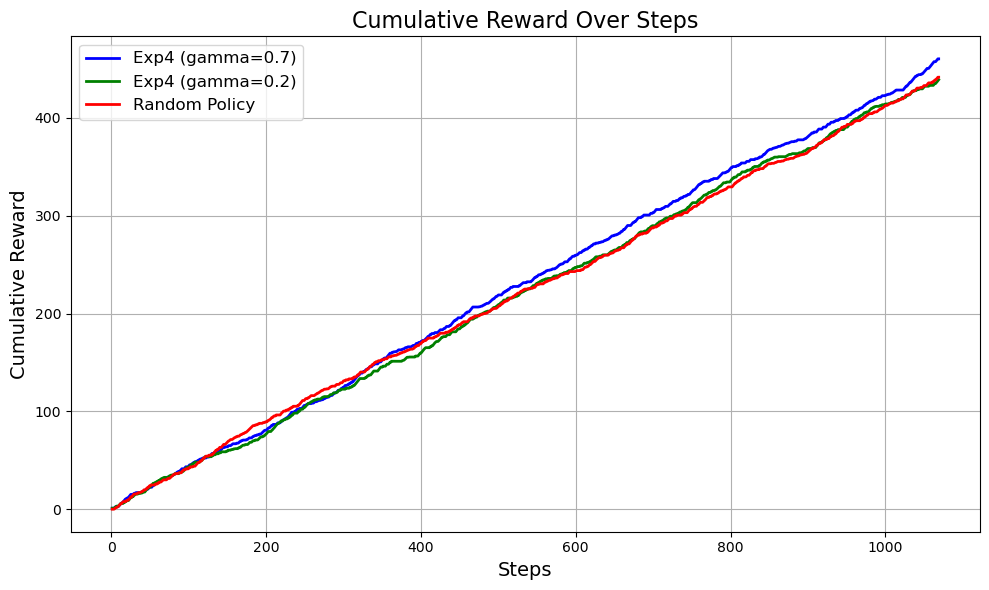

In [308]:
plt.figure(figsize=(10, 6))

# Plot Exp4 best-cum
steps_cum = np.arange(1, len(cum_cum) + 1)
plt.plot(steps_cum, cum_cum, linewidth=2, color='b',
         label=f'Exp4 (gamma={best_gamma_cum})')

# Plot Exp4 best-avg
steps_avg = np.arange(1, len(cum_avg) + 1)
plt.plot(steps_avg, cum_avg, linewidth=2, color='g',
         label=f'Exp4 (gamma={best_gamma_avg})')

# Plot random policy
steps_rand = np.arange(1, len(cum_rand) + 1)
plt.plot(steps_rand, cum_rand, linewidth=2, color='r',
         label='Random Policy')

# Titles and labels
plt.title('Cumulative Reward Over Steps', fontsize=16)
plt.xlabel('Steps', fontsize=14)
plt.ylabel('Cumulative Reward', fontsize=14)

# Use log-scale on the x-axis
# plt.xscale('log')

# Grid & Legend
plt.grid(True)

# Legend
plt.legend(fontsize=12)
filename = f'Exp4 vs Random - Cumulative Defined Reward Over Steps (Log Scale).png'
full_path = os.path.join(box_path + save_dir, filename)  
# plt.savefig(full_path, dpi=300)


plt.tight_layout()
# Show the figure
plt.show()

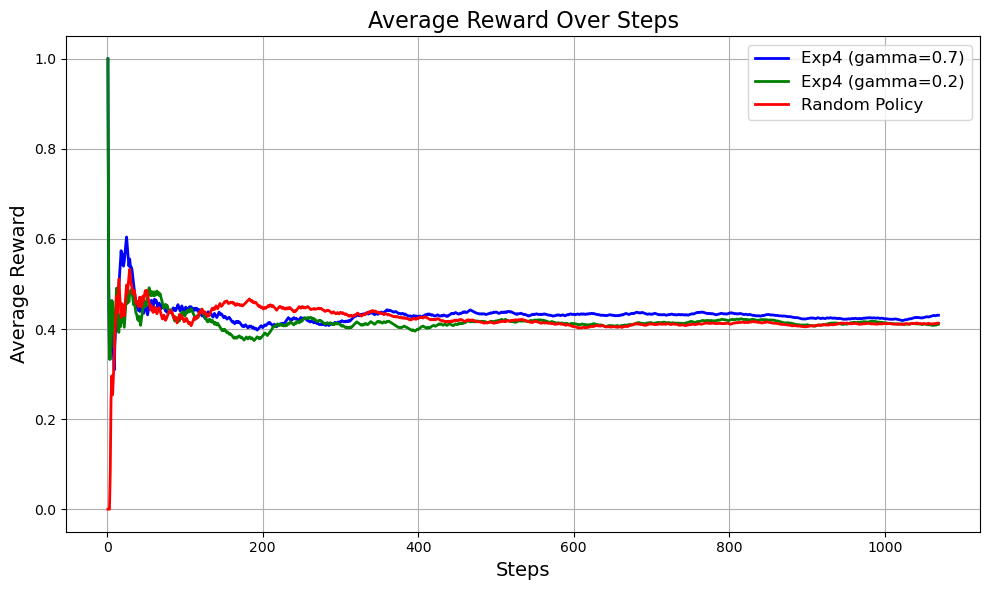

In [310]:
def compute_average_rewards(reward_history):
    # cumulative sum up to step t
    cumsum_rewards = np.cumsum(reward_history)
    steps = np.arange(1, len(cumsum_rewards) + 1)
    # average reward at step t = cumsum_rewards[t-1] / t
    avg_rewards = cumsum_rewards / steps  
    return avg_rewards

avg_cum = compute_average_rewards(reward_history_cum)   # Exp4 best-cum
avg_avg = compute_average_rewards(reward_history_avg)   # Exp4 best-avg
avg_rand = compute_average_rewards(reward_history_rand) # random policy

# 2) Plot each on the same figure
plt.figure(figsize=(10, 6))

# Exp4 best-cum
steps_cum = np.arange(1, len(avg_cum) + 1)
plt.plot(steps_cum, avg_cum, linewidth=2, color='b',
         label=f'Exp4 (gamma={best_gamma_cum})')

# Exp4 best-avg
steps_avg = np.arange(1, len(avg_avg) + 1)
plt.plot(steps_avg, avg_avg, linewidth=2, color='g',
         label=f'Exp4 (gamma={best_gamma_avg})')

# Random policy
steps_rand = np.arange(1, len(avg_rand) + 1)
plt.plot(steps_rand, avg_rand, linewidth=2, color='r',
         label='Random Policy')

# 3) Customize the plot
plt.title('Average Reward Over Steps', fontsize=16)
plt.xlabel('Steps', fontsize=14)
plt.ylabel('Average Reward', fontsize=14)

# If you want a log-scale on the x-axis:
# plt.xscale('log')

# Grid & Legend
plt.grid(True)

# Legend
plt.legend(fontsize=12)
filename = f'Exp4 vs Random - Average Defined Reward Over Steps (Log Scale).png'
full_path = os.path.join(box_path + save_dir, filename)  
# plt.savefig(full_path, dpi=300)


plt.tight_layout()
# Show the figure
plt.show()

### Picking the best Advisor
The result may be influenced by two factors: reward and advisor. First, we will attempt to identify and select the best advisor—one that can classify actions in relation to the context with greater accuracy.

#### Logistic Regression without considering the Previous Reported Trust

In [194]:
columns = ['GazeDuration', 'mean_dist', 'min_dist', 'max_dist',
           'std_dist', 'mean_agv_spd', 'min_agv_spd', 'max_agv_spd', 'std_spd', 'PerfectAutomation', 'TrustPropensity',
           'AutomationExperience', 'User_Relative_Speed', 'AGV_Relative_Speed', 'Frechet_Distance_10', 'Duration', 'AGV_User_Distance_Min']
columns_to_scale = ['GazeDuration', 'mean_dist', 'min_dist', 'max_dist',
                    'std_dist', 'mean_agv_spd', 'min_agv_spd', 'max_agv_spd', 'std_spd', 'PerfectAutomation', 'TrustPropensity',
                    'AutomationExperience', 'User_Relative_Speed', 'AGV_Relative_Speed', 'Frechet_Distance_10', 'Duration', 'AGV_User_Distance_Min']
label = 'Arm'

In [196]:
# Extract features and label
X = cross_first_data[columns]
y = cross_first_data.Arm

In [198]:
missing_values = X.isnull().sum()
print("Missing Values in Each Column:\n", missing_values)

Missing Values in Each Column:
 GazeDuration             0
mean_dist                0
min_dist                 0
max_dist                 0
std_dist                 0
mean_agv_spd             0
min_agv_spd              0
max_agv_spd              0
std_spd                  0
PerfectAutomation        0
TrustPropensity          0
AutomationExperience     0
User_Relative_Speed      0
AGV_Relative_Speed       0
Frechet_Distance_10      0
Duration                 0
AGV_User_Distance_Min    0
dtype: int64


In [200]:
missing_values = y.isnull().sum()
print("Missing Values in Each Column:\n", missing_values)

Missing Values in Each Column:
 0


In [212]:
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = pd.DataFrame(scaler.fit_transform(X[columns_to_scale]),
                               columns=columns_to_scale,
                               index=X.index)

# Replace scaled columns in the feature set
for col in columns_to_scale:
    X[col] = X_scaled[col]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.37      0.50        79
           1       0.72      0.93      0.81       135

    accuracy                           0.72       214
   macro avg       0.74      0.65      0.65       214
weighted avg       0.73      0.72      0.69       214



C:\Users\HIALAB\AppData\Local\Temp\ipykernel_100572\927990016.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X_scaled[col]


#### Logistic Regression considering the Previous Reported Trust

In [263]:
columns = ['GazeDuration', 'mean_dist', 'min_dist', 'max_dist',
       'std_dist', 'mean_agv_spd', 'min_agv_spd', 'max_agv_spd', 'std_spd', 'PerfectAutomation', 'TrustPropensity',
       'AutomationExperience','User_Relative_Speed', 'AGV_Relative_Speed', 'Frechet_Distance_10', 'Duration', 'AGV_User_Distance_Min', 'Trust_before']
columns_to_scale = ['GazeDuration', 'mean_dist', 'min_dist', 'max_dist',
       'std_dist', 'mean_agv_spd', 'min_agv_spd', 'max_agv_spd', 'std_spd', 'PerfectAutomation', 'TrustPropensity',
       'AutomationExperience','User_Relative_Speed', 'AGV_Relative_Speed', 'Frechet_Distance_10', 'Duration', 'AGV_User_Distance_Min', 'Trust_before']
label = 'Arm'

In [265]:
# Drop rows where the 'Trust before' column has NaN values
LR_data = cross_first_data.dropna(subset=['Trust_before'])

# Verify the result
print("After dropping rows with NaN in 'Trust before':")
LR_data

After dropping rows with NaN in 'Trust before':


,PID,DRate,date,hr,min,s,AGVname,StartTime,EndTime,GazeDuration,...,AGV_Relative_Speed,Frechet_Distance_3,Frechet_Distance_5,Frechet_Distance_7,Frechet_Distance_10,Cross_First,Duration,Reward,AGV_User_Distance_Min,Arm
2,1,High,2024-5-3,14,28,53,3,1900-01-01 15:04:37,1900-01-01 15:05:34,268,...,120.176130,282.09,482.54,821.32,1067.08,User,57.0,0,262.097590,0
3,1,High,2024-5-3,14,28,53,4,1900-01-01 15:05:46,1900-01-01 15:06:37,779,...,263.284416,421.34,544.15,577.55,610.84,User,51.0,0,551.672375,0
6,1,High,2024-5-3,14,28,53,7,1900-01-01 15:09:07,1900-01-01 15:09:50,537,...,228.573947,379.71,540.52,665.30,941.60,User,43.0,1,598.393526,0
7,1,High,2024-5-3,14,28,53,8,1900-01-01 15:10:07,1900-01-01 15:11:08,650,...,161.124764,331.78,693.33,1038.91,1483.72,User,61.0,0,705.402875,0
8,1,High,2024-5-3,14,28,53,9,1900-01-01 15:11:12,1900-01-01 15:12:13,856,...,161.124877,115.79,379.19,541.15,1029.62,AGV,61.0,1,572.331091,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1316,46,Low,2024-8-26,16,55,4,11,1900-01-01 17:06:07,1900-01-01 17:06:55,0,...,138.147470,350.85,667.28,943.82,1367.78,AGV,48.0,0,921.824016,1
1317,46,Low,2024-8-26,16,55,4,12,1900-01-01 17:07:02,1900-01-01 17:08:21,595,...,90.961763,224.51,507.80,789.37,1176.65,User,79.0,0,684.410781,0
1318,46,Low,2024-8-26,16,55,4,13,1900-01-01 17:08:24,1900-01-01 17:09:05,0,...,286.165319,420.27,627.75,714.38,937.14,AGV,41.0,1,1180.664614,1
1319,46,Low,2024-8-26,16,55,4,14,1900-01-01 17:09:08,1900-01-01 17:09:52,0,...,221.787091,408.09,668.13,919.97,1180.07,User,44.0,0,804.919339,0


In [267]:
# Extract features and label
# Extract features and label
X = LR_data[columns]
y = LR_data.Arm

In [269]:
missing_values = X.isnull().sum()
print("Missing Values in Each Column:\n", missing_values)

Missing Values in Each Column:
 GazeDuration             0
mean_dist                0
min_dist                 0
max_dist                 0
std_dist                 0
mean_agv_spd             0
min_agv_spd              0
max_agv_spd              0
std_spd                  0
PerfectAutomation        0
TrustPropensity          0
AutomationExperience     0
User_Relative_Speed      0
AGV_Relative_Speed       0
Frechet_Distance_10      0
Duration                 0
AGV_User_Distance_Min    0
Trust_before             0
dtype: int64


In [271]:
missing_values = y.isnull().sum()
print("Missing Values in Each Column:\n", missing_values)

Missing Values in Each Column:
 0


In [248]:
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = pd.DataFrame(scaler.fit_transform(X[columns_to_scale]),
                               columns=columns_to_scale,
                               index=X.index)

# Replace scaled columns in the feature set
for col in columns_to_scale:
    X[col] = X_scaled[col]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.35      0.47        71
           1       0.73      0.93      0.82       136

    accuracy                           0.73       207
   macro avg       0.72      0.64      0.64       207
weighted avg       0.73      0.73      0.70       207



C:\Users\HIALAB\AppData\Local\Temp\ipykernel_100572\927990016.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X_scaled[col]


C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


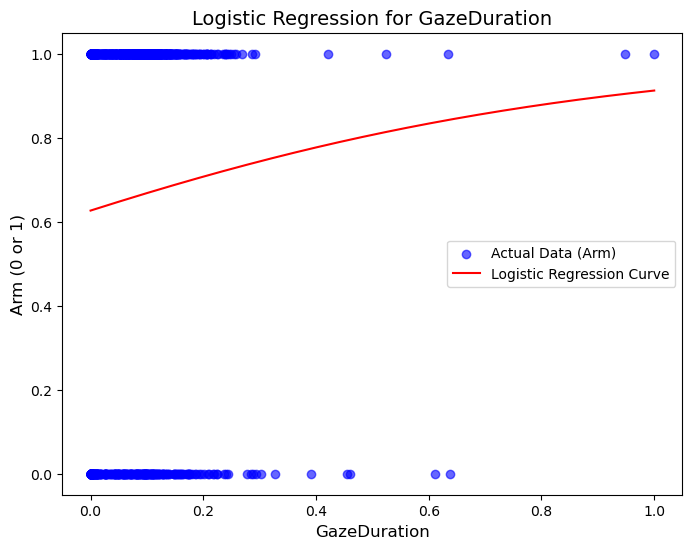

C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


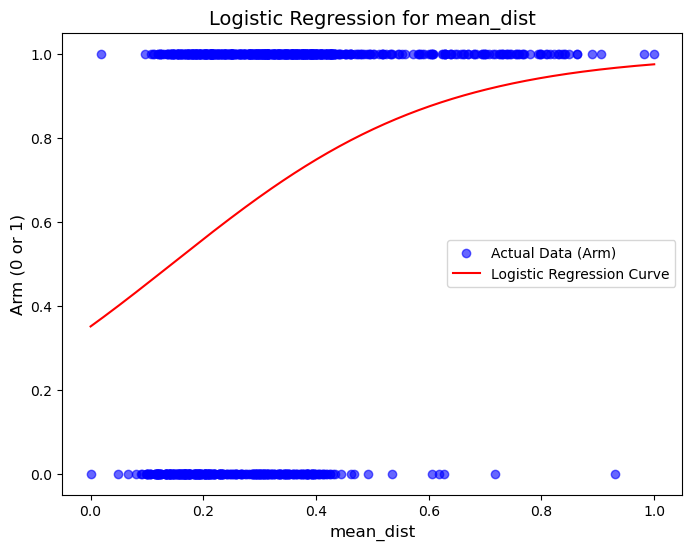

C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


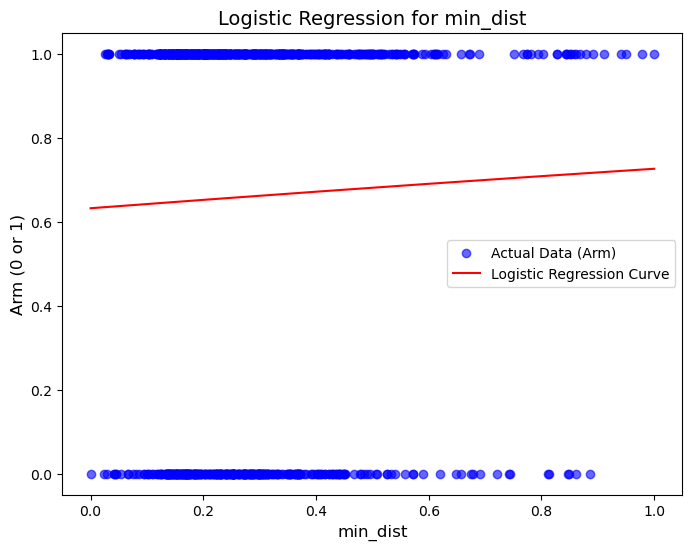

C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


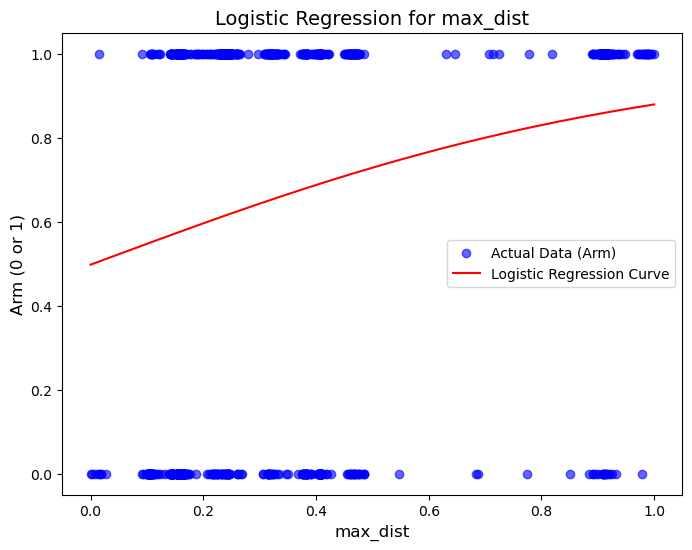

C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


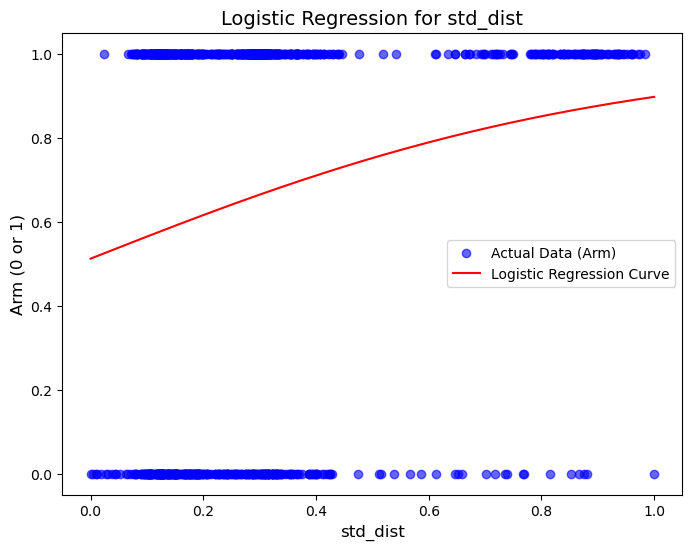

C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


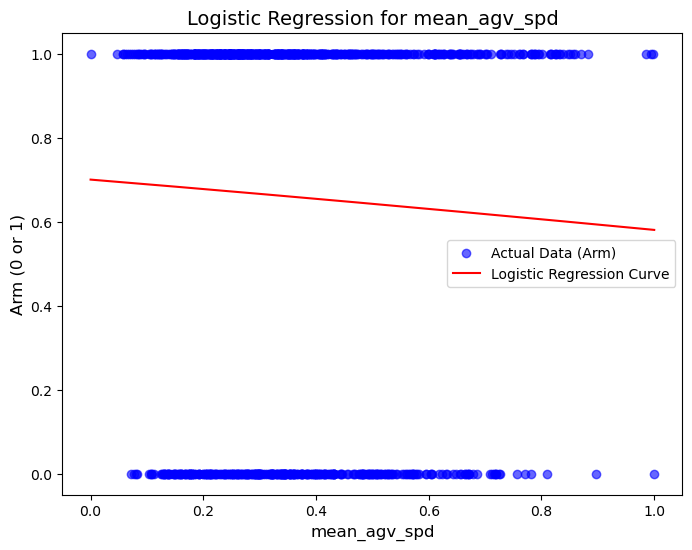

C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


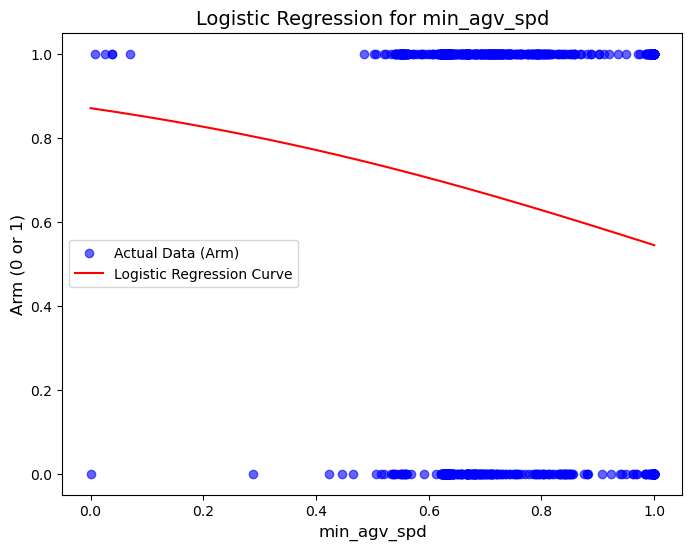

C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


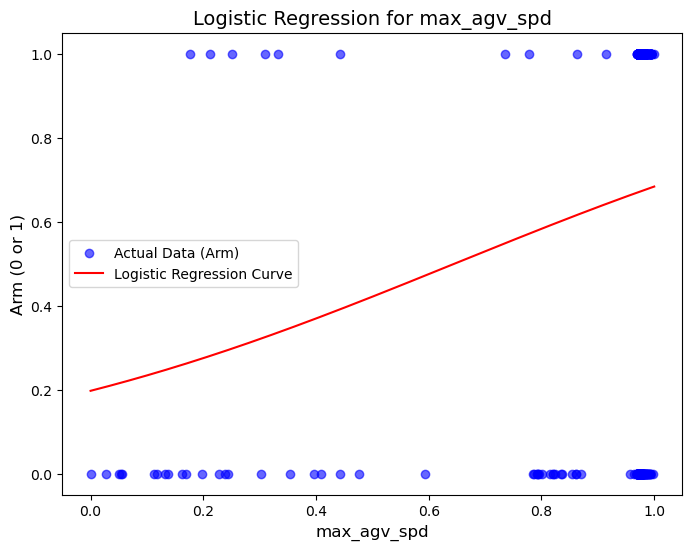

C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


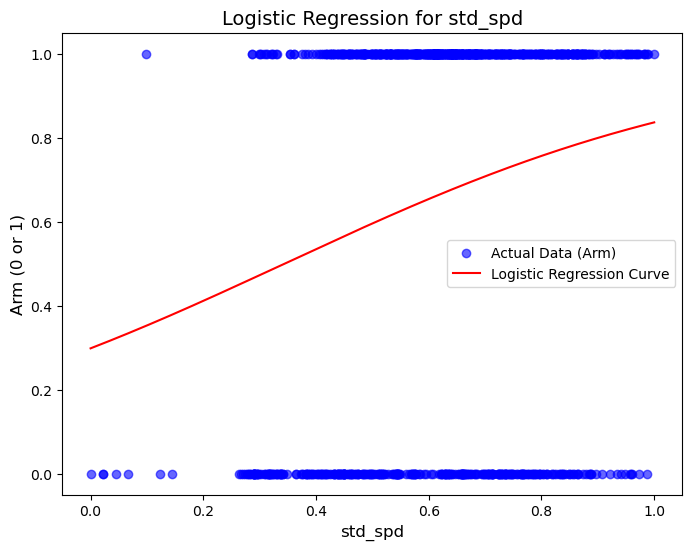

C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


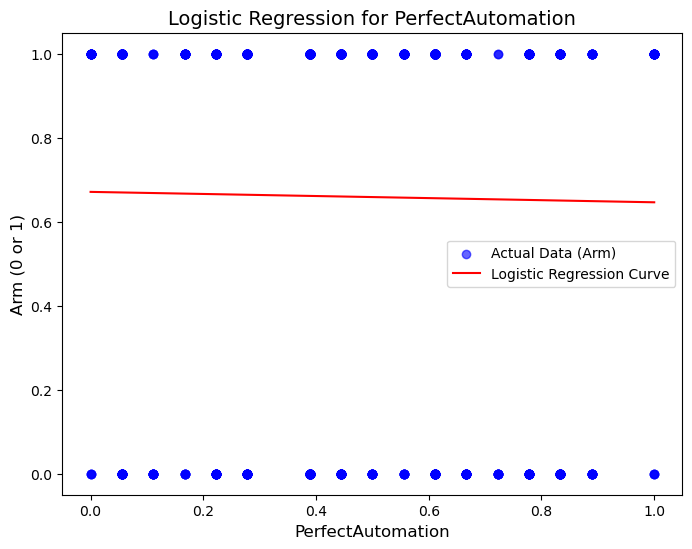

C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


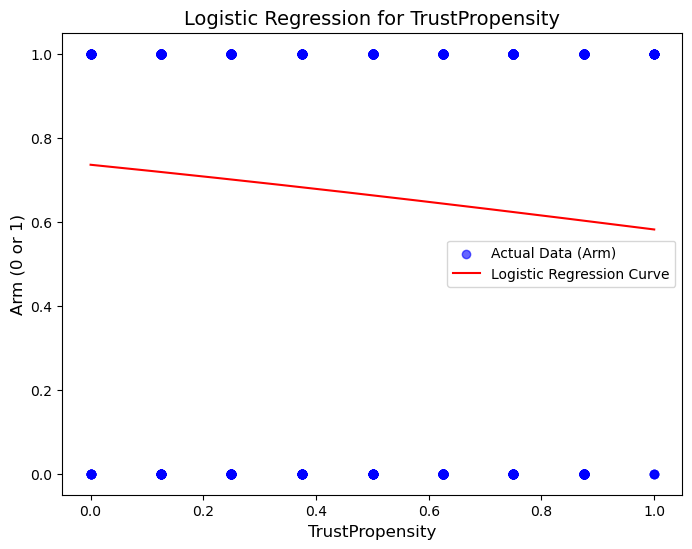

C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


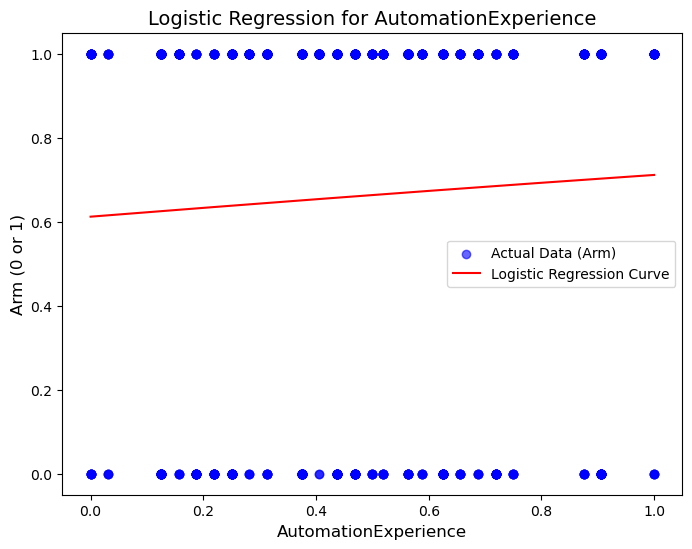

C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


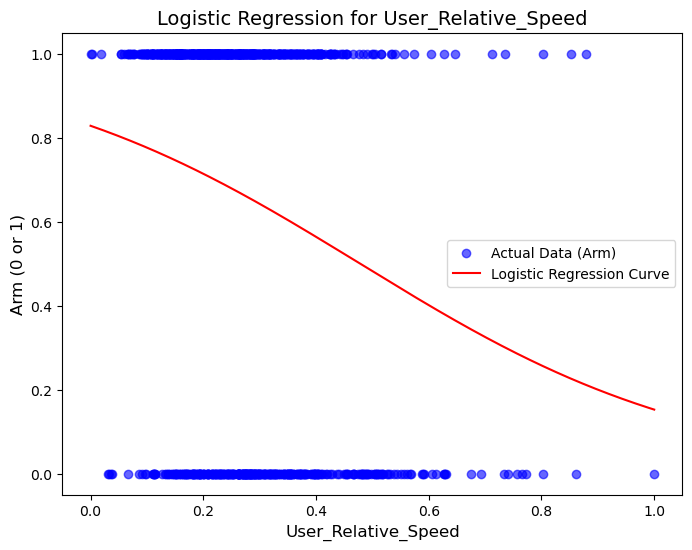

C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


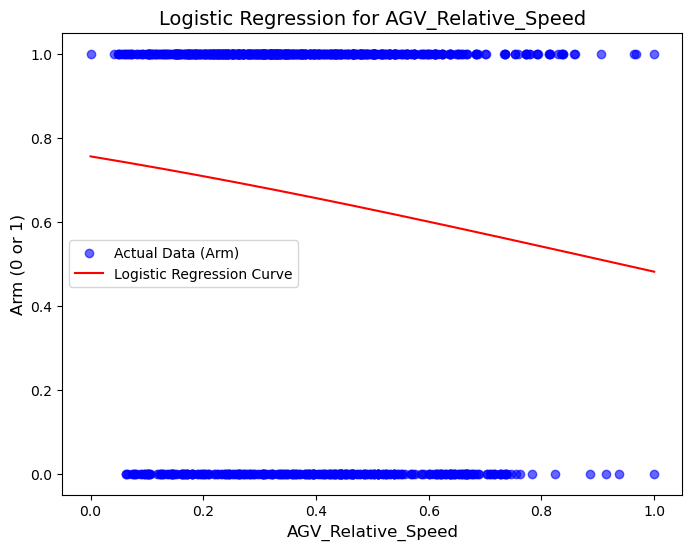

C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


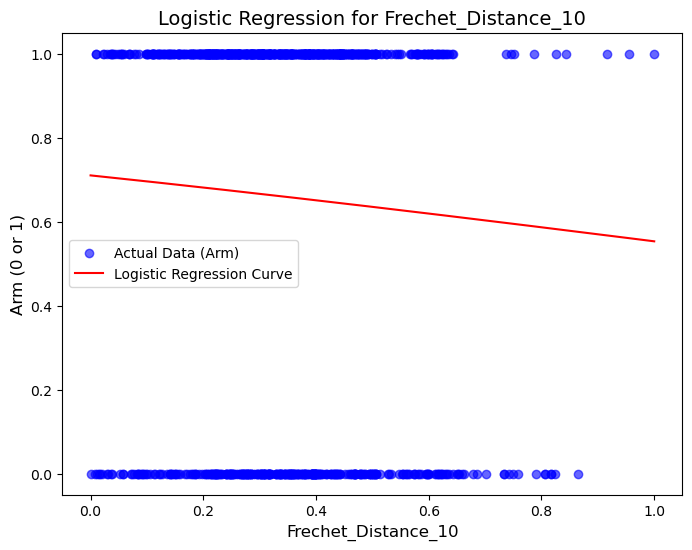

C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


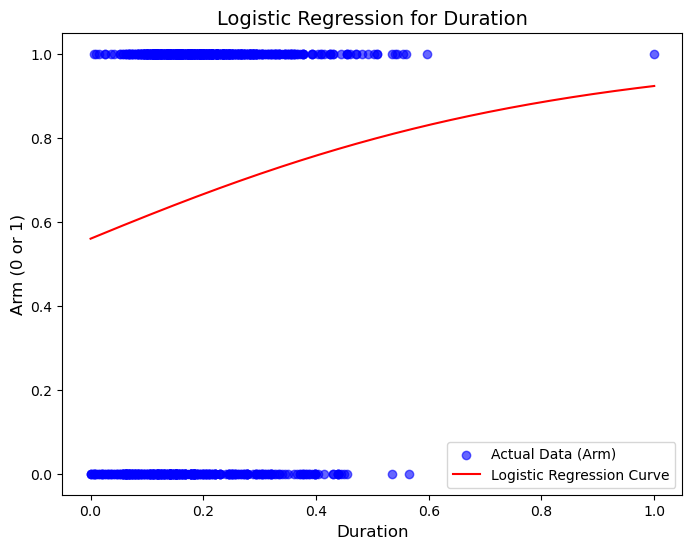

C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


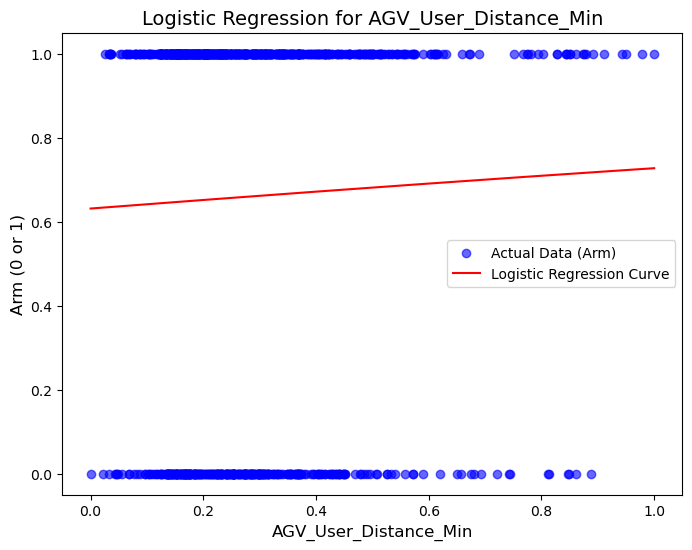

C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


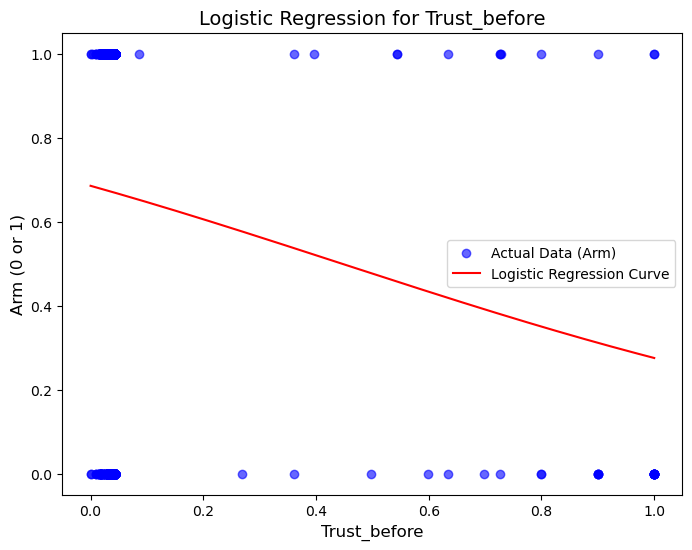

In [277]:
# Loop through each feature and plot
for feature in columns_to_scale:
    # Logistic Regression Model
    model = LogisticRegression(random_state=42)
    model.fit(X_train[[feature]], y_train)  # Train using a single feature

    # Generate data for the logistic regression curve
    X_plot = np.linspace(X[feature].min(), X[feature].max(), 300).reshape(-1, 1)
    y_plot = model.predict_proba(X_plot)[:, 1]  # Probabilities for class 1

    # Plot the data points and the logistic regression curve
    plt.figure(figsize=(8, 6))
    plt.scatter(X[feature], y, label='Actual Data (Arm)', color='blue', alpha=0.6)
    plt.plot(X_plot, y_plot, label='Logistic Regression Curve', color='red')
    plt.xlabel(feature, fontsize=12)
    plt.ylabel('Arm (0 or 1)', fontsize=12)
    plt.title(f'Logistic Regression for {feature}', fontsize=14)
    plt.legend()
    plt.show()